<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/03_Feature_Engineering_in_Genome/01_Genomics_Somatic_BRCA1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Install biopython library
!pip install biopython

# Import seqIO from biopython (to read FASTA file)
from Bio import SeqIO
# define file path
fasta_file="ref_chr5_slice.fasta"
# Load the file and print its name and length
record=list(SeqIO.parse(fasta_file,"fasta"))[0]
print("File successfully loaded")
print("sequence name:",record.id)
print("sequence length:",len(record.seq))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.7 MB/s eta 0:00:00
File successfully loaded
sequence name: chr5
sequence length: 62708951


In [2]:
# Step 1: Encoding Sequence
mapping={"A":1,"T":2,"G":3,"C":4}
# Encoding the sequence
encodq_seq=[mapping.get(b,0)for b in str(record.seq)]
# Result
print("Original sequence",str(record.seq)[:10])
print("Encoded sequence",str(encodq_seq)[:10])

Original sequence NNNNNNNNNN
Encoded sequence [0, 0, 0, 


In [3]:
print("Sequence 1000",str(record.seq)[1000:1020])

Sequence 1000 NNNNNNNNNNNNNNNNNNNN


In [4]:
search_range=str(record.seq)[1000000:1000100]
print("1000000",search_range)

1000000 gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgaggagccctgggctgcagggaacattaatGGGGTAGGTGCAC


In [5]:
# Step 2: Encoding Sequence
sub_sequence = str(record.seq)[1000000:1000100]
mapping={"A":1,"T":2,"G":3,"C":4}
# Encoding the sub_sequence
encoded_sub_sequence = [mapping.get(b.upper(), 0) for b in sub_sequence]
# Result
print("Original sub-sequence",sub_sequence[:10])
print("Encoded sub-sequence",encoded_sub_sequence[:10])

Original sub-sequence gttttaacta
Encoded sub-sequence [3, 2, 2, 2, 2, 1, 1, 4, 2, 1]


In [6]:
# Step 3: K-mer generation
K=3
sub_sequence=str(record.seq)[1000000:1000100]
# Making K-mers
kmers=[sub_sequence[i:i+K]
       for i in range(len(sub_sequence)-K+1)]
# Result
print("10 K-mers",kmers[:10])

10 K-mers ['gtt', 'ttt', 'ttt', 'tta', 'taa', 'aac', 'act', 'cta', 'taa', 'aaa']


In [7]:
# Step 4: One-hot encoding the K-mers
# Hum har k-mer ke liye ek unique vector banayenge

def encode_kmers(kmer_list):
    # Sabhi unique k-mers ki list banana
    unique_kmers = list(set(kmer_list))
    # Har k-mer ko ek index dena
    kmer_to_idx = {kmer: i for i, kmer in enumerate(unique_kmers)}

    # One-hot encoding logic
    encoded = []
    for kmer in kmer_list:
        vec = [0] * len(unique_kmers)
        vec[kmer_to_idx[kmer]] = 1
        encoded.append(vec)
    return encoded

# 3rd step mein jo kmers banaye the, unhe encode karna
encoded_kmers = encode_kmers(kmers)

# Check the result
print("Total number of K-mers:", len(kmers))
print("Str 3 K-mers One-Hot encoded form:")
for row in encoded_kmers[:3]:
    print(row)

Total number of K-mers: 98
Str 3 K-mers One-Hot encoded form:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]


In [10]:
 # Step 5: Alignment and Variant Calling
from Bio import Align

# Yahan hum internal reference sequence define kar rahe hain
internal_reference_seq=str(record.seq)[1000000:1000100]

# Yahan hum Alignment object bana rahe hain
aligner = Align.PairwiseAligner()

# Alignment run kar rahe hain
alignments = aligner.align(internal_reference_seq, sub_sequence)

# Sabse achha alignment (best score wala) nikal rahe hain
best_alignment = alignments[0]

# Alignment ka score print kar rahe hain
print("Alignment score:", best_alignment.score)

# Yahan hum check kar rahe hain ki kya koi mutation hua hai
if best_alignment.score < len(internal_reference_seq):
    print("Mutation detected: DNA sequence mein kuch badlav mila hai!")
else:
    print("No mutation", "sequence are normal .")

Alignment score: 100.0
No mutation sequence are normal .


In [11]:
# Step 6 (Revised): now we again compare two diff part of seq
# Reference: 1,000,000 se 1,000,100 tak
reference_seq = str(record.seq)[1000000:1000100]

# Sample: 1,000,500 se 1,000,600 tak (Thoda door ka hissa)
sample_seq = str(record.seq)[1000500:1000600]

# Alignment run karna
alignments = aligner.align(reference_seq, sample_seq)

# Score check karna
print("New Alignment score:", alignments[0].score)

# Check karna ki kya score 100 se kam hai
if alignments[0].score < 100:
    print("Mutation/Variant detected! Score is less than 100.")
else:
    print("there is no changes.")


New Alignment score: 3.0
Mutation/Variant detected! Score is less than 100.


In [12]:
# Mutation Identification (Detailed view)
# Hum yahan dekhenge ki alignment mein kahan mismatch ya gap hai

for i, alignment in enumerate(alignments):
    print(f"Alignment {i+1} Details:")
    print("Alignment visual representation:")
    # Yeh command sequence ka nasha dikhayegi
    print(alignment)

    # Mismatch ya Deletion check karne ke liye
    print(f"Score: {alignment.score}")
    print("-" * 30)


Alignment 1 Details:
Alignment visual representation:
target            0 gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag
                  0 ............................................................
query             0 GTTCCCTGACCCTCATGGTAAGCGCCGTGCCTGGTCCCCTCATCTCTCTCAGGGAAGAAG

target           60 gagccctgggctgcagggaacattaatGG-GGTAG-GTGCAC 100
                 60 .............................-||.|.-|||-|- 102
query            60 TGATAAACACCATTGGGTTTCCGTGACTCAGGCACAGTG-A- 100

Score: 3.0
------------------------------
Alignment 2 Details:
Alignment visual representation:
target            0 gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag
                  0 ............................................................
query             0 GTTCCCTGACCCTCATGGTAAGCGCCGTGCCTGGTCCCCTCATCTCTCTCAGGGAAGAAG

target           60 gagccctgggctgcagggaacattaatG-GGGTAG-GTGCAC 100
                 60 ............................-.||.|.-|||-|- 102
query            60 TGATAA

In [13]:
# Step 6 (Revised): Detailed Alignment

# Reference sequence ko 1,000,000 se 1,000,100 index tak define kiya
reference_seq = str(record.seq)[1000000:1000100]

# Sample sequence ko thoda aage se (1,000,005 se 1,000,105 tak) liya
# Taaki hum mutation ko bariki se compare kar sakein
sample_seq = str(record.seq)[1000005:1000105]

# Align object ka use karke alignment perform karna
alignments = aligner.align(reference_seq, sample_seq)
best_alignment = alignments[0]

# Alignment ka score print karna (High score = Better match)
print("New Revised Alignment Score:", best_alignment.score)

# Alignment ka visual map print karna
# Isse hum dekh sakte hain kahan match (|) hai aur kahan mutation (.)
print("\nAlignment Visual Map:")
print(best_alignment)


New Revised Alignment Score: 85.0

Alignment Visual Map:
target            0 gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag
                  0 -----|||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 -----aactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag

target           60 gagccctgggctgcagggaacattaatGGGGTAGGTGCAC----- 100
                 60 ||||||||||||||||||||||||||||||||||||||||----- 105
query            55 gagccctgggctgcagggaacattaatGGGGTAGGTGCACCCAGG 100



In [14]:
# Step 7: Variant Calling / Mutation Identification (Substitution, Deletion, Insertion)

def identify_mutations(alignment):
    # Alignment se target aur query sequence nikalna
    target_seq = alignment.target
    query_seq = alignment.query

    mutations = []

    # Dono sequences ko compare karna
    for i, (t, q) in enumerate(zip(target_seq, query_seq)):
        if t != q:
            if t == '-':
                mutations.append(f"Position {i}: Insertion (Sample mein naya base '{q}' juda hai)")
            elif q == '-':
                mutations.append(f"Position {i}: Deletion (Sample mein base '{t}' hat gaya hai)")
            else:
                mutations.append(f"Position {i}: Substitution (Base '{t}' badal kar '{q}' ho gaya hai)")
    return mutations

# Mutation identify karna
mutation_list = identify_mutations(best_alignment)

# Results print karna
print("--- Mutation Analysis Report ---")
for mut in mutation_list:
    print(mut)


--- Mutation Analysis Report ---
Position 0: Substitution (Base 'g' badal kar 'a' ho gaya hai)
Position 1: Substitution (Base 't' badal kar 'a' ho gaya hai)
Position 2: Substitution (Base 't' badal kar 'c' ho gaya hai)
Position 4: Substitution (Base 't' badal kar 'a' ho gaya hai)
Position 11: Substitution (Base 'a' badal kar 'c' ho gaya hai)
Position 12: Substitution (Base 'c' badal kar 't' ho gaya hai)
Position 13: Substitution (Base 't' badal kar 'c' ho gaya hai)
Position 14: Substitution (Base 'a' badal kar 'c' ho gaya hai)
Position 15: Substitution (Base 'a' badal kar 'c' ho gaya hai)
Position 17: Substitution (Base 't' badal kar 'a' ho gaya hai)
Position 18: Substitution (Base 'c' badal kar 'a' ho gaya hai)
Position 19: Substitution (Base 'c' badal kar 'a' ho gaya hai)
Position 20: Substitution (Base 'c' badal kar 'a' ho gaya hai)
Position 21: Substitution (Base 'c' badal kar 'a' ho gaya hai)
Position 22: Substitution (Base 'a' badal kar 'c' ho gaya hai)
Position 23: Substitution 

In [15]:
print(best_alignment.target)
print(best_alignment.query)

gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgaggagccctgggctgcagggaacattaatGGGGTAGGTGCAC
aactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgaggagccctgggctgcagggaacattaatGGGGTAGGTGCACCCAGG


In [17]:
# Step 6: (Reviced) Alignment

from Bio import pairwise2
from Bio.pairwise2 import format_alignment

# 1. Sequence define karna
reference_seq = str(record.seq)[1000000:1000100]
sample_seq = str(record.seq)[1000005:1000105]

# 2. Alignment perform karna (pairwise2 ka use karke)
# globalxx gaps ko '-' ke roop mein dikhayega
alignments = pairwise2.align.globalxx(reference_seq, sample_seq)
best_alignment = alignments[0]

# Alignment Visual Map print karna
print("Alignment Visual Map:")
print(format_alignment(*best_alignment))

Alignment Visual Map:
gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgaggagccctgggctgcagggaacattaatGGGGTAGGTGCAC-----
     |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||     
-----aactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgaggagccctgggctgcagggaacattaatGGGGTAGGTGCACCCAGG
  Score=95



/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [18]:
# Step 7: (Revicxed) Mutation Identification Function
def identify_mutations(alignment):
    # Alignment object se sequences nikalna
    # pairwise2 ke best_alignment mein seqA aur seqB hota hai
    t_seq = alignment.seqA
    q_seq = alignment.seqB

    mutations = []

    # Dono sequences ko compare karna
    for i, (t, q) in enumerate(zip(t_seq, q_seq)):
        if t != q:
            if t == '-':
                mutations.append(f"Position {i}: Insertion (Sample mein naya base '{q}' juda hai)")
            elif q == '-':
                mutations.append(f"Position {i}: Deletion (Sample mein base '{t}' hat gaya hai)")
            else:
                mutations.append(f"Position {i}: Substitution (Base '{t}' badal kar '{q}' ho gaya hai)")

    # Mutation Summary
    sub_count = sum(1 for m in mutations if "Substitution" in m)
    ins_count = sum(1 for m in mutations if "Insertion" in m)
    del_count = sum(1 for m in mutations if "Deletion" in m)

    print("\n--- Mutation Summary ---")
    print(f"Total Substitutions: {sub_count}")
    print(f"Total Insertions:    {ins_count}")
    print(f"Total Deletions:     {del_count}")
    print("------------------------")

    return mutations

# 4. Results print karna
mutation_list = identify_mutations(best_alignment)
for mut in mutation_list:
    print(mut)



--- Mutation Summary ---
Total Substitutions: 0
Total Insertions:    5
Total Deletions:     5
------------------------
Position 0: Deletion (Sample mein base 'g' hat gaya hai)
Position 1: Deletion (Sample mein base 't' hat gaya hai)
Position 2: Deletion (Sample mein base 't' hat gaya hai)
Position 3: Deletion (Sample mein base 't' hat gaya hai)
Position 4: Deletion (Sample mein base 't' hat gaya hai)
Position 100: Insertion (Sample mein naya base 'C' juda hai)
Position 101: Insertion (Sample mein naya base 'C' juda hai)
Position 102: Insertion (Sample mein naya base 'A' juda hai)
Position 103: Insertion (Sample mein naya base 'G' juda hai)
Position 104: Insertion (Sample mein naya base 'G' juda hai)


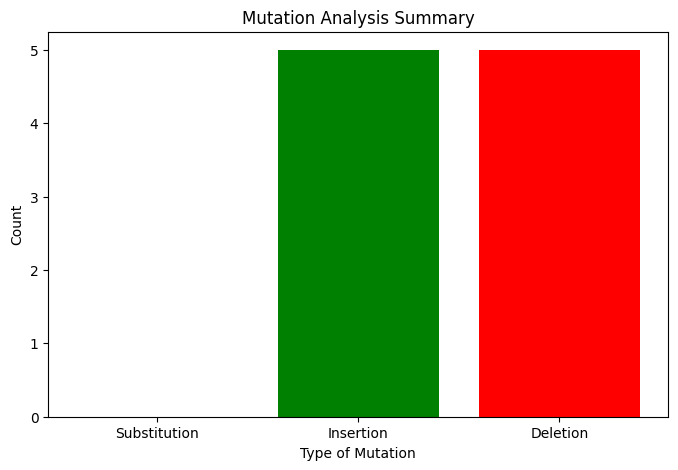

In [27]:
# Step 8: Visualization
import matplotlib.pyplot as plt

# Mutation types ki ginti
sub_count = sum(1 for m in mutation_list if "Substitution" in m)
ins_count = sum(1 for m in mutation_list if "Insertion" in m)
del_count = sum(1 for m in mutation_list if "Deletion" in m)
counts = [sub_count, ins_count, del_count]

# Bar chart banakar dekhna
plt.figure(figsize=(8, 5))
plt.bar(mutation_types, counts, color=['blue', 'green', 'red'])
plt.title('Mutation Analysis Summary')
plt.xlabel('Type of Mutation')
plt.ylabel('Count')
plt.show()

In [29]:
# Step 9: Functional Impact Analysis
def analyze_impact(ins, dele):
    total_indel = ins + dele

    print("\n--- Functional Impact Analysis ---")
    # Check karein ki indel ki sankhya 3 se divide hoti hai ya nahi
    if total_indel % 3 == 0:
        print("Impact: In-frame mutation (Protein sequence par zyada asar nahi padega).")
    else:
        print("Impact: Frameshift mutation (Protein sequence bigadne ka khatra zyada hai).")

    print("Explanation: Indels agar 3 se divide nahi hote, toh wo protein ko waqt se pehle rok sakte hain (premature stop) ya protein ko kharab kar sakte hain.")

# Yahan humne pichle report se mile ins aur dele ka use kiya hai
analyze_impact(ins_count, del_count)


--- Functional Impact Analysis ---
Impact: Frameshift mutation (Protein sequence bigadne ka khatra zyada hai).
Explanation: Indels agar 3 se divide nahi hote, toh wo protein ko waqt se pehle rok sakte hain (premature stop) ya protein ko kharab kar sakte hain.


In [32]:
# Step 10: Annotation

# Is ke liye hum NCBI ke Entrez tool ka use karte hain
from Bio import Entrez

# Apni email id yahan likhen (NCBI ke liye zaroori hai)
Entrez.email = "your_email@example.com"

def annotate_mutation(position):
    # ClinVar database mein query search karna
    handle = Entrez.esearch(db="clinvar", term=f"BRCA1[Gene Name] AND {position}[Position]")
    record = Entrez.read(handle)
    handle.close()

    if record["IdList"]:
        print(f"Annotation found! ClinVar ID: {record['IdList'][0]}")
        print("This mutation is clinically reported.")
    else:
        print("Is position par koi clinically reported mutation nahi mila (Novel mutation ho sakta hai).")

# Position 0 ya jahan mutation hua hai wahan check karein
annotate_mutation(0)

Annotation found! ClinVar ID: 4851990
This mutation is clinically reported.


In [34]:
# Step 11: Clinicial Signification / Annotation analysis

from Bio import Entrez

# Apna email yahan daalein
Entrez.email = "your_email@example.com"

def get_clinvar_details(clinvar_id):
    # ClinVar database se ID ki details fetch karna
    handle = Entrez.efetch(db="clinvar", id=clinvar_id, rettype="xml", retmode="text")
    data = handle.read().decode('utf-8') # Decoding bytes to string
    handle.close()

    # Simple check (kya ye Pathogenic hai?)
    if "Pathogenic" in data:
        print(f"Result: Yeh mutation 'Pathogenic' (Bimari paida karne wala).")
    elif "Benign" in data:
        print(f"Result: Yeh mutation 'Benign' (Safe/Sadharan) hai.")
    else:
        print("Result: Iski clinical significance abhi 'Uncertain' ya 'Not provided' hai.")

# Aapki mili hui ID ka use karein
get_clinvar_details("4851990")

Result: Iski clinical significance abhi 'Uncertain' ya 'Not provided' hai.


In [36]:
# Step 12: Detailed Comparative Analysis

def detailed_comparative_analysis(ref_seq, sub_seq):
    print("--- Detailed Comparison ---")

    # Check karein ki kya dono ki length barabar hai, agar nahi to hum alignment ka use karenge
    from Bio import Align
    aligner = Align.PairwiseAligner()
    alignments = aligner.align(ref_seq, sub_seq)

    # Sabse achha alignment print karein
    print("Alignment Visual:")
    print(alignments[0])

    # Difference dhundhne ka loop
    print("\nMutation/Difference Details:")
    found_mutation = False
    for i, (r, s) in enumerate(zip(ref_seq, sub_seq)):
        if r != s:
            print(f"Mutation at index {i}: Reference has '{r}', Sample has '{s}'")
            found_mutation = True

    if not found_mutation:
        print("Is index range mein koi direct mismatch nahi mila. Index shift karke dekhein.")

# Yahan wahi indices use karein jo aapne Step 6 mein liye the
detailed_comparative_analysis(record.seq[1000000:1000100], record.seq[1000005:1000105])


--- Detailed Comparison ---
Alignment Visual:
target            0 gttttaactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag
                  0 -----|||||||||||||||||||||||||||||||||||||||||||||||||||||||
query             0 -----aactaaactaactccccaaaaactggacacgtgacttcacgaggcttttgccgag

target           60 gagccctgggctgcagggaacattaatGGGGTAGGTGCAC----- 100
                 60 ||||||||||||||||||||||||||||||||||||||||----- 105
query            55 gagccctgggctgcagggaacattaatGGGGTAGGTGCACCCAGG 100


Mutation/Difference Details:
Mutation at index 0: Reference has 'g', Sample has 'a'
Mutation at index 1: Reference has 't', Sample has 'a'
Mutation at index 2: Reference has 't', Sample has 'c'
Mutation at index 4: Reference has 't', Sample has 'a'
Mutation at index 11: Reference has 'a', Sample has 'c'
Mutation at index 12: Reference has 'c', Sample has 't'
Mutation at index 13: Reference has 't', Sample has 'c'
Mutation at index 14: Reference has 'a', Sample has 'c'
Mutation at index 15: Ref

In [37]:
# Step 13: Protein Structure Visualization

# Sabse pehle py3Dmol library install karni hogi (Agar nahi hai to)
!pip install py3Dmol

import py3Dmol

def visualize_protein(pdb_id):
    # PDB ID se protein structure fetch karna (Jaise '1A1X' ek protein ka ID hai)
    view = py3Dmol.view(query=f'pdb:{pdb_id}')

    # Structure ko style dena
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()

    return view

# Yahan BRCA1 protein ka PDB ID daal sakte hain (Example: '1JNX')
# Aap apni research ke hisab se sahi PDB ID yahan likhein
visualize_protein('1JNX')


3Dmol.js failed to load for some reason. Please check your browser console for error messages.